# Recovering an option-implied probability density
## Milestone 1: a controlled synthetic benchmark
Joel Cerraga | Quant research project | Development version 0.1

**Status:** synthetic validation completed; empirical SPX analysis has not yet begun. All inputs are illustrative, not observed market values.

The preliminary objective is to establish whether numerical differentiation of European call prices recovers a known terminal distribution. This allows numerical errors to be assessed before introducing discrete, noisy market quotes. The notebook accompanies `research/methodology.md`.

### 1. What are we recovering?
A call pays $\max(S_T-K,0)$ at expiry. Here, $S_T$ is the terminal index level, $K$ is the strike and $T$ is time to expiry in years. A density is not the probability of a single exact outcome: integrating it over an interval gives that interval's probability.

As Bahra (1997) explains in his Bank of England working paper [1], a European call can be valued by discounting its expected payoff under the risk-neutral distribution. Under deterministic interest rates and a continuous density, this gives Equation (1):
$$C(K,T)=e^{-rT}\int_K^\infty(s-K)f_Q(s;T)\,ds.\tag{1}$$
Following the option-price differentiation approach discussed by Bahra [1], differentiating Equation (1) once with respect to strike gives Equation (2):
$$\frac{\partial C}{\partial K}=-e^{-rT}\int_K^\infty f_Q(s;T)\,ds.\tag{2}$$
The boundary term vanishes because the payoff is zero at $s=K$. Breeden and Litzenberger (1978) established the extraction relationship [6]; following its derivation in Bahra [1], differentiating Equation (2) again gives Equation (3):
$$f_Q(K;T)=e^{rT}\frac{\partial^2C}{\partial K^2}.\tag{3}$$
As Bahra [1] emphasises, the recovered probabilities are risk-neutral pricing probabilities, rather than direct real-world forecasts. Differentiation is across strikes at a fixed maturity and observation date.

### 2. Controlled experiment
Black and Scholes (1973) derive option valuation from a no-arbitrage argument [8]. As Bahra [1] explains, the corresponding constant-volatility benchmark has a lognormal terminal distribution. We use this model as a known answer. The continuous-dividend adjustment used in the code is consistent with the spot–forward relationship set out by Aït-Sahalia and Lo (1998), Equation (16) [10]. This is an implementation check, not a claim that SPX returns follow this model. Spot = 6,000; annual continuously compounded rate = 4%; dividend yield = 1.5%; annual volatility = 20%; maturity = 0.5 years.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from density import Parameters, call_price, exact_density, recover_density, diagnostics
p = Parameters()
print(p)

Parameters(spot=6000.0, rate=0.04, dividend=0.015, volatility=0.2, maturity=0.5)


### 3. Price the calls and recover the density
As Driscoll and Braun explain in *Fundamentals of Numerical Computation*, §5.4 [7], a second derivative can be approximated using a three-point centred difference. For equally spaced strikes separated by $h$, applying their Equation (5.4.9) to Equation (3) gives Equation (4):
$$\widehat f_Q(K_i)=e^{rT}\frac{C(K_i+h)-2C(K_i)+C(K_i-h)}{h^2}.\tag{4}$$
The Taylor-expansion argument described by Driscoll and Braun, §5.5 [7], gives a truncation error of order $h^2$ for Equation (4), provided the price function is sufficiently smooth. We exclude grid endpoints, where a centred stencil is unavailable. No clipping of negative values or renormalisation is performed.

In [2]:
strikes = np.arange(2500., 14000.1, 5.)
calls = call_price(strikes, p)
levels, recovered = recover_density(strikes, calls, p.rate, p.maturity)
print(f'{len(strikes)} call prices; {len(levels)} interior density estimates')

2301 call prices; 2299 interior density estimates


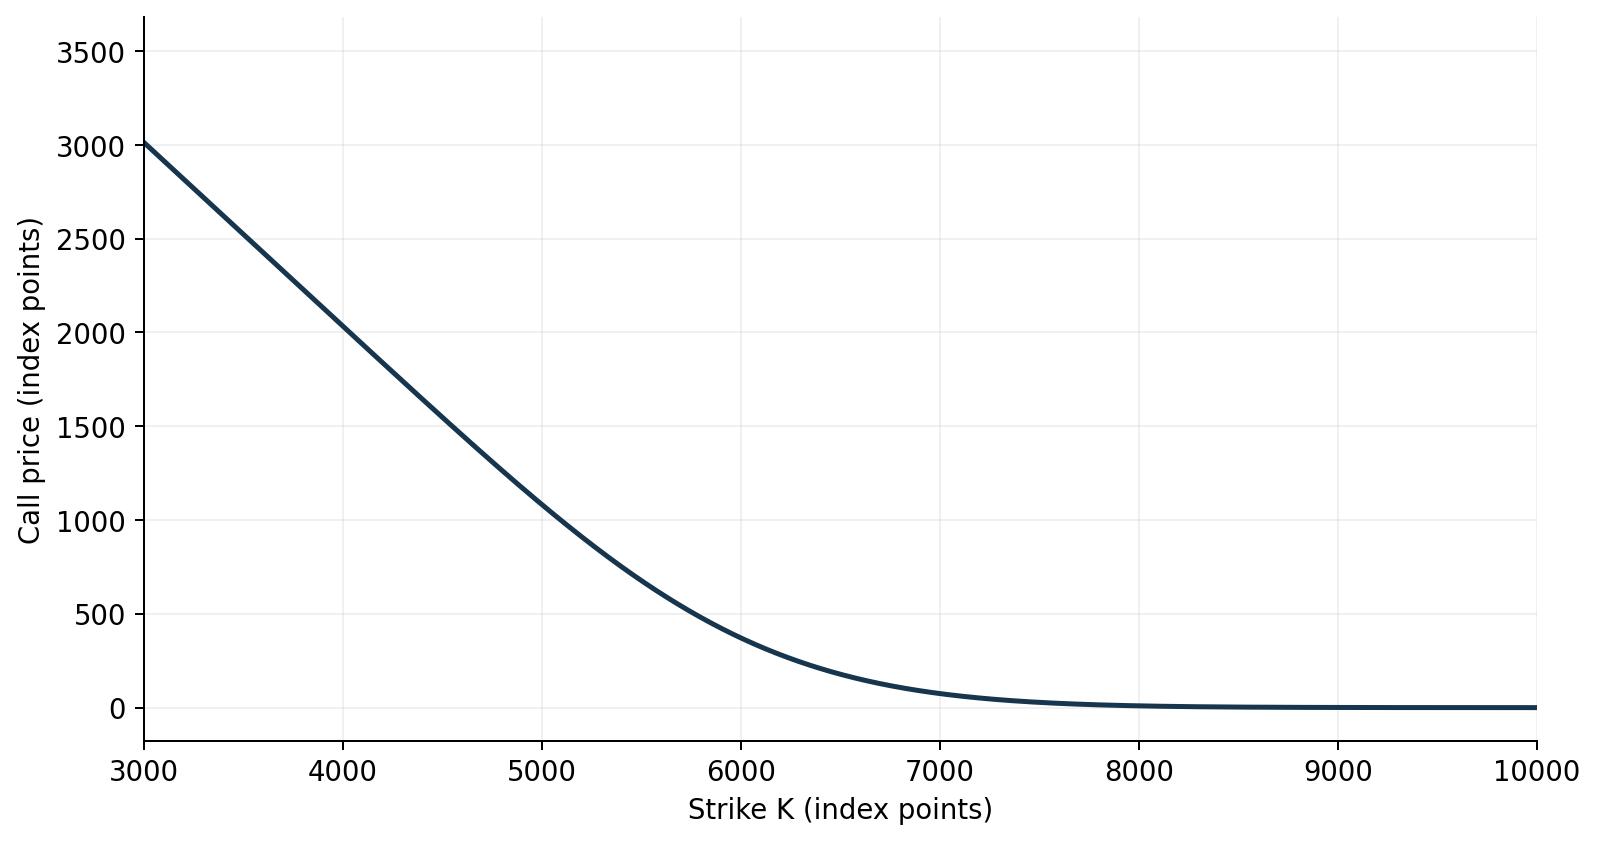

In [3]:

from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/figure_01_call_prices.png')))


Figure 1. Synthetic European call prices across strikes for a six-month expiry, using an illustrative initial index level of 6,000 and constant annual volatility of 20%.

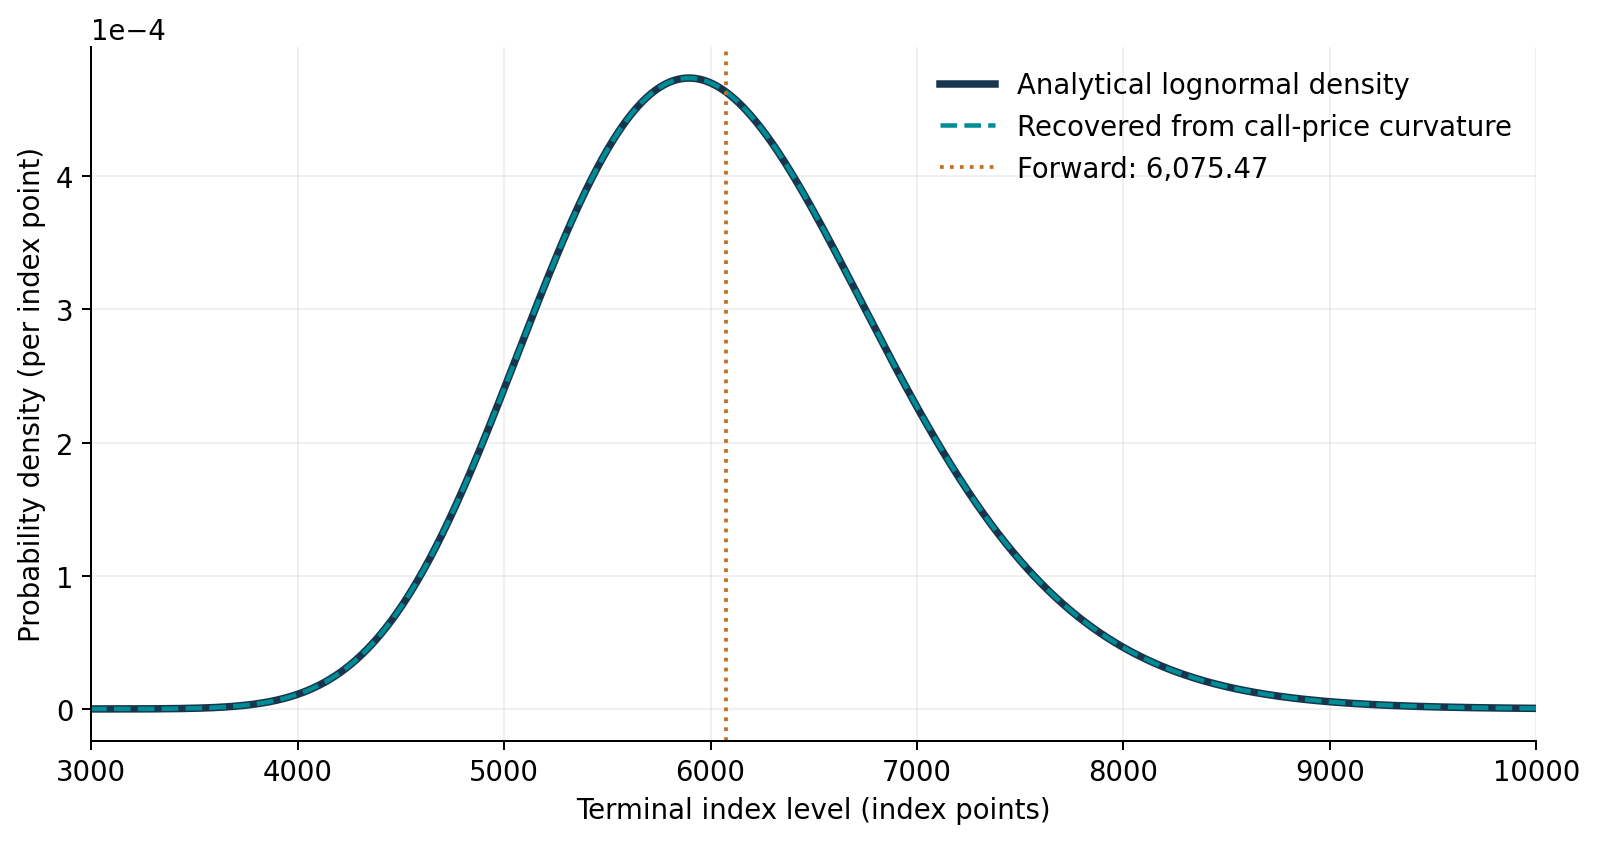

In [4]:

from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/figure_02_density_recovery.png')))


Figure 2. Analytical lognormal density and density recovered from synthetic call-price curvature. The dashed vertical line identifies the theoretical forward of 6,075.47. The recovered and analytical curves nearly coincide.

As shown in Figure 2, the density is concentrated near the initial index level and has a longer right tail in index-level coordinates. This shape follows from the assumed lognormal model; it is not an empirical finding about current markets. Bahra’s Mathematical appendix identifies the forward with the risk-neutral mean [1]; it should not be confused with the mode.

In [5]:
metrics = diagnostics(levels, recovered, p)
print(json.dumps(metrics, indent=2))
assert abs(metrics['mass'] - 1) < 1e-7
assert metrics['negative_density_count'] == 0
assert metrics['integrated_absolute_error'] < 1e-5
assert metrics['forward_relative_error'] < 1e-7
assert metrics['max_repricing_error_index_points'] < 0.01
print('All five baseline acceptance checks passed.')

{
  "mass": 0.9999999985279788,
  "minimum_density": 3.649747692016563e-12,
  "negative_density_count": 0,
  "integrated_absolute_error": 2.914825705338636e-06,
  "first_moment": 6075.470691653079,
  "theoretical_forward": 6075.470709243807,
  "forward_relative_error": 2.8953687479907275e-09,
  "max_repricing_error_index_points": 1.0992562238243409e-05
}
All five baseline acceptance checks passed.


### 4. Convergence and failure modes
The grid is refined from 80 to 5 index points. The integrated absolute error measures total disagreement between recovered and analytical densities. Figure 3 compares the observed error with the second-order convergence expected from Equation (4).

h=80: integrated absolute error=0.00074513593
h=40: integrated absolute error=0.00018651327
h=20: integrated absolute error=4.6636576e-05
h=10: integrated absolute error=1.1659344e-05
h= 5: integrated absolute error=2.9148257e-06


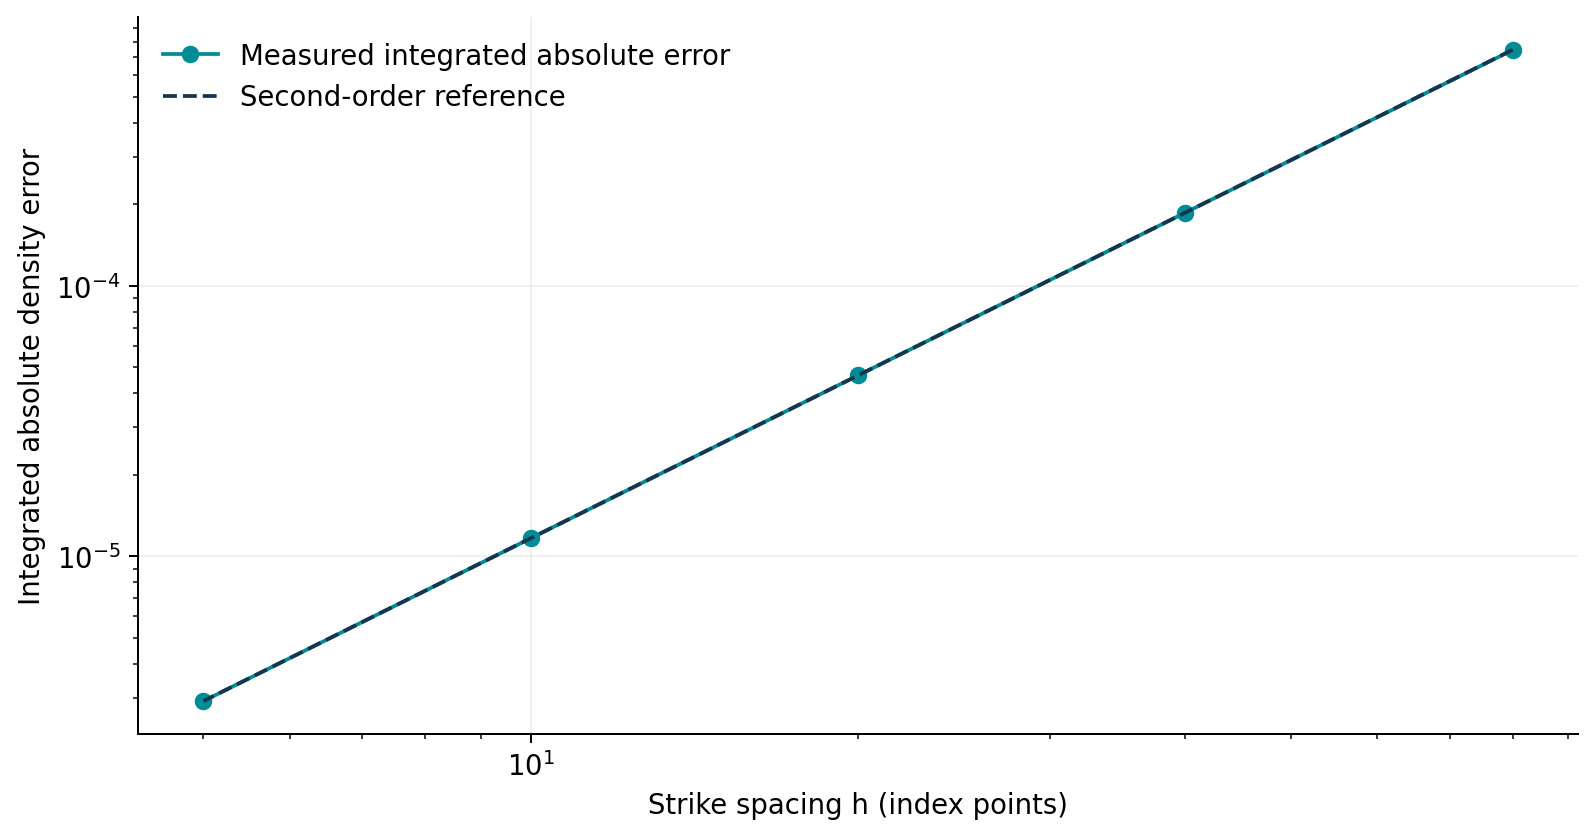

In [6]:
errors = []
for h in [80, 40, 20, 10, 5]:
    k = np.arange(2500., 14000.1, h)
    x, f = recover_density(k, call_price(k, p), p.rate, p.maturity)
    error = diagnostics(x, f, p)['integrated_absolute_error']
    errors.append(error)
    print(f'h={h:2d}: integrated absolute error={error:.8g}')
assert all(b < a for a, b in zip(errors, errors[1:]))
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/figure_03_convergence.png')))


Figure 3. Integrated absolute density error against strike spacing. The measured error follows approximately second-order convergence over the tested grid spacings.

Negative density estimates: 34.7%


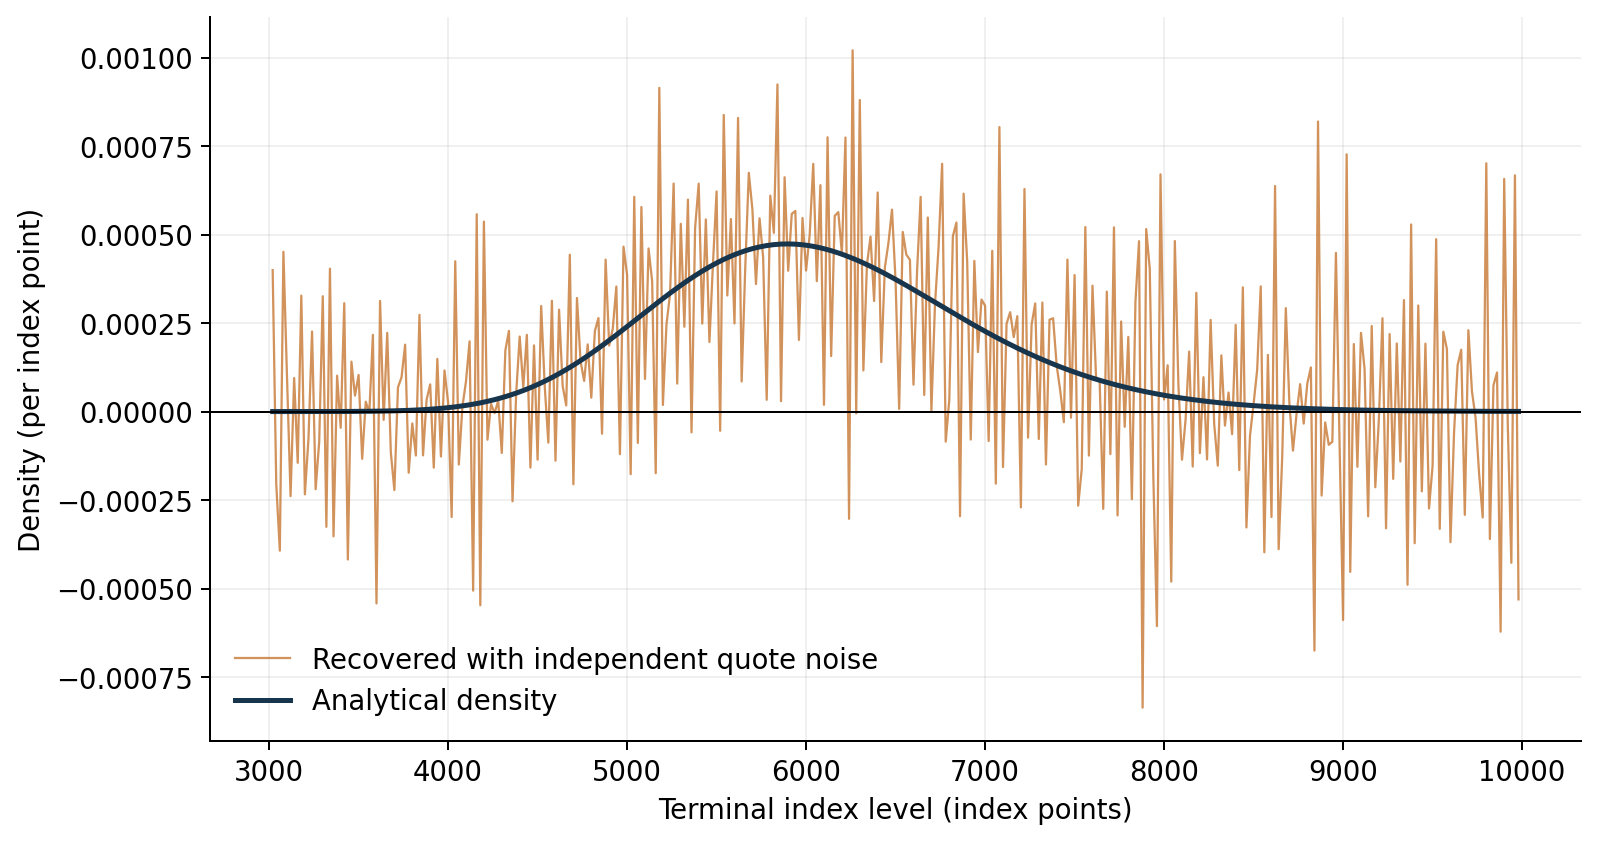

In [7]:
rng = np.random.default_rng(42)
k = np.arange(3000., 10000.1, 20.)
noisy = call_price(k, p) + rng.normal(0, 0.05, len(k))
x, noisy_density = recover_density(k, noisy, p.rate, p.maturity)
print(f'Negative density estimates: {np.mean(noisy_density < 0):.1%}')
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'figures/figure_04_noise_sensitivity.png')))


Figure 4. Density recovered after adding independent, zero-mean quote noise with a standard deviation of 0.05 index points (seed 42). Negative estimates demonstrate the sensitivity of raw second differences to quote errors.

Figure 4 introduces independent zero-mean quote perturbations with a standard deviation of 0.05 index points and seed 42. These errors need not preserve arbitrage constraints. Applying Equation (4) amplifies their effect through division by the squared strike spacing. This is an algebraic consequence of the stencil in Driscoll and Braun [7], rather than a calibrated model of market noise. The stress test deliberately shows the consequence of applying raw differences to inconsistent quotes; it is not a fitted market-noise model.

**Boundary decision.** An initial lower strike of 1,000 caused tiny negative second differences from floating-point cancellation in the far left tail. The validated grid uses 2,500–14,000 (interior density points 2,505–13,995). This is a model-specific numerical choice; no clipping is performed.

### 5. Interpretation and next stage
This experiment validates the clean-data implementation within the tested settings. It does not validate a method for real quotes. Finite support leaves unobserved tail mass; here the range is broad enough for the stated tolerances. As Driscoll and Braun discuss in §5.5 [7], reducing the step size can eventually increase roundoff error through subtractive cancellation.

The next stage will assess accessible SPX quotes, document timestamp and settlement conventions, and choose a shape-constrained fitting method. Aït-Sahalia and Duarte (2003) show why monotonicity and convexity restrictions matter when estimating option-price curves [9]. This motivates our planned constrained fit; their particular estimator has not yet been implemented. Quote cleaning, forward consistency and tail treatment remain separate requirements. Clipping negative densities cannot substitute for addressing inconsistent input prices.

### References

[1] B. Bahra (1997), “Implied risk-neutral probability density functions from option prices: theory and application,” Bank of England, Working Paper No. 66. Sections 2.1–2.2 and Mathematical appendix. [Full paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/1997/implied-risk-neutral-probability-density-functions-from-option-prices.pdf).

[6] D. T. Breeden and R. H. Litzenberger (1978), “Prices of State-Contingent Claims Implicit in Option Prices,” *The Journal of Business*, vol. 51, no. 4, pp. 621–651. [doi:10.1086/260618](https://doi.org/10.1086/260618). Original attribution; the derivation was consulted through Bahra [1] and Aït-Sahalia and Lo [10].

[7] T. A. Driscoll and R. J. Braun, *Fundamentals of Numerical Computation*, author-maintained online textbook, §§5.4–5.5. [Finite differences, especially Equation (5.4.9)](https://fncbook.com/finitediffs/); [Convergence and roundoff](https://fncbook.com/fd-converge/). Accessed 19 September 2026.

[8] F. Black and M. Scholes (1973), “The Pricing of Options and Corporate Liabilities,” *Journal of Political Economy*, vol. 81, no. 3, pp. 637–654. [doi:10.1086/260062](https://doi.org/10.1086/260062). Publisher abstract and metadata consulted; the lognormal implementation is supported by [1] and [10].

[9] Y. Aït-Sahalia and J. Duarte (2003), “Nonparametric option pricing under shape restrictions,” *Journal of Econometrics*, vol. 116, nos. 1–2, pp. 9–47. Section 2. [doi:10.1016/S0304-4076(03)00102-7](https://doi.org/10.1016/S0304-4076(03)00102-7); [author-hosted paper](https://www.princeton.edu/~yacine/cnvx.pdf).

[10] Y. Aït-Sahalia and A. W. Lo (1998), “Nonparametric Estimation of State-Price Densities Implicit in Financial Asset Prices,” *The Journal of Finance*, vol. 53, no. 2, pp. 499–547. Sections I and III.A, especially Equations (16)–(17). [Author-hosted paper](https://www.princeton.edu/~yacine/aslo.pdf).
